# Хорды, механизмы адаптации и цена адаптации ЛЖ

## Цель ноутбука

В этом ноутбуке проверяется идея, что ложные хорды ЛЖ могут быть связаны не напрямую с глобальной функцией сердца, а с тем, какой механизм адаптации ЛЖ формируется при нагрузке и какую “цену” эта адаптация имеет для региональной механики.

Под “механизмом адаптации” здесь понимается принадлежность пациента к одному из механико-гемодинамических фенотипов, выделенных по переменным:

- `dsws` — прирост САД на нагрузке;
- `echo_lv_sws_delta_g_cm2` — прирост систолического напряжения стенки ЛЖ;
- `echo_lv_sphericity_index_end_systolic_ratio` — индекс сферичности ЛЖ в конце систолы;
- `echo_lv_sphericity_index_end_diastolic_ratio` — индекс сферичности ЛЖ в конце диастолы.

Под “ценой адаптации” понимается степень региональной механической неоднородности, которую можно оценить через:

- `echo_lv_strain_plus_cv_pct`;
- `echo_lv_strain_rate_cv_pct`;
- `dicor_ssou_cv_pct`;
- `dicor_sm_kdtr_cv_pct`.

## Основная физиологическая идея

Ложные хорды ЛЖ рассматриваются как возможные внутренние механические ограничения. Они могут не снижать EF напрямую, но потенциально могут менять распределение нагрузки внутри ЛЖ.

Поэтому основной вопрос:

> Связаны ли разные типы хорд с разными механизмами адаптации ЛЖ и с разной ценой этой адаптации?

## Рабочие гипотезы

### H1. Архитектура хорд связана с механизмом адаптации

Поперечные, distant и complex/multi-zone хорды могут чаще встречаться в стресс-доминантном фенотипе адаптации.

### H2. Количество хорд менее важно, чем их ориентация и топология

Простое количество хорд может быть слабее связано с механикой, чем ориентация, распространённость и топология хорд.

### H3. Стресс-доминантный фенотип может иметь большую цену адаптации

Ожидается, что стресс-доминантный фенотип будет связан с более высокой вариабельностью strain, strain rate и DICOR-показателей.

### H4. Геометрически-сферичный фенотип может быть компенсаторным

Более сферичная геометрия ЛЖ не обязательно означает большую механическую неоднородность. Она может быть отдельным вариантом адаптации.

### H5. Самая высокая цена адаптации может возникать при сочетании:

```text
сложная / поперечная архитектура хорд
+
стресс-доминантный фенотип адаптации

In [18]:
# ============================================================
# 0. Минимальная служебная ячейка: импорты и пути
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path(
    r"C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords"
)

DATA_PATH = PROJECT_ROOT / "data" / "final_analysis_dataset_ver2.xlsx"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "05_chords_adaptation_costs"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Импорты загружены")
print("DATA_PATH:", DATA_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

Импорты загружены
DATA_PATH: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\data\final_analysis_dataset_ver2.xlsx
OUTPUT_DIR: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs


In [19]:
# ============================================================
# 1. Загрузка данных и определение групп переменных
# ============================================================

df = pd.read_excel(DATA_PATH)

print(f"Размер исходного датасета: {df.shape[0]} строк × {df.shape[1]} колонок")

# ------------------------------------------------------------
# Переменные механизма адаптации
# ------------------------------------------------------------

adaptation_vars = [
    "dsws",
    "echo_lv_sws_delta_g_cm2",
    "echo_lv_sphericity_index_end_systolic_ratio",
    "echo_lv_sphericity_index_end_diastolic_ratio",
]

# ------------------------------------------------------------
# Переменные хорд
# ------------------------------------------------------------

chord_vars = [
    "lv_false_tendon_total_count",
    "Chord_Orientation",
    "Chord_Spread_Class",
    "Chord_Topology_Class",
]

# ------------------------------------------------------------
# Переменные “цены адаптации”
# ------------------------------------------------------------

adaptation_cost_vars = [
    "echo_lv_strain_plus_cv_pct",
    "echo_lv_strain_rate_cv_pct",
    "dicor_ssou_cv_pct",
    "dicor_sm_kdtr_cv_pct",
]

# ------------------------------------------------------------
# Базовые ковариаты, если понадобятся позже
# ------------------------------------------------------------

baseline_covariates = [
    "age_years",
    "sex",
    "body_surface_area_m2",
    "body_mass_index_kg_m2",
]

# ------------------------------------------------------------
# Красивые названия для графиков
# ------------------------------------------------------------

pretty_names = {
    "dsws": "ΔСАД на нагрузке, мм рт. ст.",
    "echo_lv_sws_delta_g_cm2": "ΔSWS ЛЖ, г/см²",
    "echo_lv_sphericity_index_end_systolic_ratio": "Индекс сферичности ЛЖ, КС",
    "echo_lv_sphericity_index_end_diastolic_ratio": "Индекс сферичности ЛЖ, КД",

    "lv_false_tendon_total_count": "Количество ложных хорд",
    "Chord_Orientation": "Ориентация хорд",
    "Chord_Spread_Class": "Распространённость хорд",
    "Chord_Topology_Class": "Топология хорд",

    "echo_lv_strain_plus_cv_pct": "CV strain, %",
    "echo_lv_strain_rate_cv_pct": "CV strain rate, %",
    "dicor_ssou_cv_pct": "DICOR CV ССОУ, %",
    "dicor_sm_kdtr_cv_pct": "DICOR CV КДТР, %",
}

# ------------------------------------------------------------
# Проверка наличия переменных
# ------------------------------------------------------------

variable_groups = {
    "adaptation_vars": adaptation_vars,
    "chord_vars": chord_vars,
    "adaptation_cost_vars": adaptation_cost_vars,
    "baseline_covariates": baseline_covariates,
}

for group_name, vars_list in variable_groups.items():
    existing = [col for col in vars_list if col in df.columns]
    missing = [col for col in vars_list if col not in df.columns]

    print(f"\n{group_name}")
    print("  Найдены:", existing)
    print("  Не найдены:", missing)

Размер исходного датасета: 153 строк × 222 колонок

adaptation_vars
  Найдены: ['dsws', 'echo_lv_sws_delta_g_cm2', 'echo_lv_sphericity_index_end_systolic_ratio', 'echo_lv_sphericity_index_end_diastolic_ratio']
  Не найдены: []

chord_vars
  Найдены: ['lv_false_tendon_total_count']
  Не найдены: ['Chord_Orientation', 'Chord_Spread_Class', 'Chord_Topology_Class']

adaptation_cost_vars
  Найдены: ['echo_lv_strain_plus_cv_pct', 'echo_lv_strain_rate_cv_pct', 'dicor_ssou_cv_pct', 'dicor_sm_kdtr_cv_pct']
  Не найдены: []

baseline_covariates
  Найдены: ['sex']
  Не найдены: ['age_years', 'body_surface_area_m2', 'body_mass_index_kg_m2']


In [20]:
# ============================================================
# 2. Аудит ключевых переменных
# ============================================================

all_key_vars = adaptation_vars + chord_vars + adaptation_cost_vars + baseline_covariates
all_key_vars_existing = [col for col in all_key_vars if col in df.columns]

audit_table = pd.DataFrame({
    "variable": all_key_vars_existing,
    "dtype": [str(df[col].dtype) for col in all_key_vars_existing],
    "n_non_missing": [df[col].notna().sum() for col in all_key_vars_existing],
    "n_missing": [df[col].isna().sum() for col in all_key_vars_existing],
    "pct_missing": [(df[col].isna().mean() * 100).round(2) for col in all_key_vars_existing],
    "n_unique": [df[col].nunique(dropna=True) for col in all_key_vars_existing],
})

display(audit_table)

audit_table.to_excel(TABLES_DIR / "00_key_variables_audit.xlsx", index=False)

print("Таблица сохранена:", TABLES_DIR / "00_key_variables_audit.xlsx")

,variable,dtype,n_non_missing,n_missing,pct_missing,n_unique
0,dsws,float64,66,87,56.86,30
1,echo_lv_sws_delta_g_cm2,float64,33,120,78.43,33
2,echo_lv_sphericity_index_end_systolic_ratio,float64,100,53,34.64,74
3,echo_lv_sphericity_index_end_diastolic_ratio,float64,100,53,34.64,72
4,lv_false_tendon_total_count,float64,132,21,13.73,7
5,echo_lv_strain_plus_cv_pct,float64,32,121,79.08,32
6,echo_lv_strain_rate_cv_pct,float64,32,121,79.08,32
7,dicor_ssou_cv_pct,float64,68,85,55.56,68
8,dicor_sm_kdtr_cv_pct,float64,68,85,55.56,56
9,sex,float64,105,48,31.37,2


Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\tables\00_key_variables_audit.xlsx


In [21]:
# ============================================================
# 3. Реконструкция механико-гемодинамических фенотипов
# ============================================================

# Рабочая таблица только по переменным адаптации
adaptation_df = df[adaptation_vars].copy()

complete_adaptation_mask = adaptation_df.notna().all(axis=1)
adaptation_complete = adaptation_df.loc[complete_adaptation_mask].copy()

print(f"Всего наблюдений в датасете: {df.shape[0]}")
print(f"Полные случаи по переменным адаптации: {adaptation_complete.shape[0]}")

# ------------------------------------------------------------
# Поиск экстремального ΔSWS через IQR
# ------------------------------------------------------------

sws_col = "echo_lv_sws_delta_g_cm2"

q1 = adaptation_complete[sws_col].quantile(0.25)
q3 = adaptation_complete[sws_col].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

sws_outlier_mask = (
    (adaptation_complete[sws_col] < lower_bound) |
    (adaptation_complete[sws_col] > upper_bound)
)

sws_outliers = adaptation_complete.loc[sws_outlier_mask].copy()
adaptation_no_outlier = adaptation_complete.loc[~sws_outlier_mask].copy()

print("\nГраницы выбросов по ΔSWS:")
print("lower_bound:", round(lower_bound, 2))
print("upper_bound:", round(upper_bound, 2))

print(f"\nКоличество экстремальных наблюдений по ΔSWS: {sws_outliers.shape[0]}")
display(sws_outliers)

print(f"\nРазмер выборки без экстремального ΔSWS: {adaptation_no_outlier.shape[0]}")

# ------------------------------------------------------------
# Z-стандартизация
# ------------------------------------------------------------

scaler = StandardScaler()

X_adaptation_scaled_array = scaler.fit_transform(adaptation_no_outlier[adaptation_vars])

X_adaptation_scaled = pd.DataFrame(
    X_adaptation_scaled_array,
    columns=adaptation_vars,
    index=adaptation_no_outlier.index,
)

# ------------------------------------------------------------
# KMeans k=3
# ------------------------------------------------------------

kmeans_3 = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=50,
)

labels_kmeans_3 = kmeans_3.fit_predict(X_adaptation_scaled)

adaptation_clusters = adaptation_no_outlier.copy()
adaptation_clusters["adaptation_cluster_k3"] = labels_kmeans_3

print("\nРазмеры кластеров:")
display(adaptation_clusters["adaptation_cluster_k3"].value_counts().sort_index())

# ------------------------------------------------------------
# Z-профили кластеров
# ------------------------------------------------------------

X_adaptation_scaled_with_clusters = X_adaptation_scaled.copy()
X_adaptation_scaled_with_clusters["adaptation_cluster_k3"] = labels_kmeans_3

z_profile_adaptation_k3 = (
    X_adaptation_scaled_with_clusters
    .groupby("adaptation_cluster_k3")[adaptation_vars]
    .mean()
)

display(z_profile_adaptation_k3.round(2))

Всего наблюдений в датасете: 153
Полные случаи по переменным адаптации: 27

Границы выбросов по ΔSWS:
lower_bound: -16.26
upper_bound: 63.06

Количество экстремальных наблюдений по ΔSWS: 1


,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio
55,21.0,135.312821,0.472,0.469



Размер выборки без экстремального ΔSWS: 26

Размеры кластеров:


adaptation_cluster_k3
0     9
1    10
2     7
Name: count, dtype: int64

,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio
adaptation_cluster_k3,,,,
0,0.27,0.08,0.93,1.04
1,-0.66,-0.80,-0.71,-0.34
2,0.59,1.05,-0.18,-0.85


In [22]:
# ============================================================
# 4. Осмысленные названия фенотипов адаптации
# ============================================================

# По ранее полученному профилю:
# cluster 0 = высокая сферичность, умеренная нагрузка
# cluster 1 = низкая нагрузка и менее сферичная геометрия
# cluster 2 = высокий dsws и высокий ΔSWS, но без сферизации

cluster_name_map = {
    0: "Sphericity-dominant phenotype",
    1: "Low load / low sphericity phenotype",
    2: "Stress-dominant phenotype",
}

cluster_name_map_ru = {
    0: "Геометрически-сферичный фенотип",
    1: "Низконагрузочный менее сферичный фенотип",
    2: "Стресс-доминантный фенотип",
}

adaptation_clusters["adaptation_phenotype"] = (
    adaptation_clusters["adaptation_cluster_k3"]
    .map(cluster_name_map)
)

adaptation_clusters["adaptation_phenotype_ru"] = (
    adaptation_clusters["adaptation_cluster_k3"]
    .map(cluster_name_map_ru)
)

# Экстремальный ΔSWS сохраняем отдельно, не смешиваем с основными кластерами
extreme_sws_df = sws_outliers.copy()
extreme_sws_df["adaptation_cluster_k3"] = pd.NA
extreme_sws_df["adaptation_phenotype"] = "Extreme ΔSWS case"
extreme_sws_df["adaptation_phenotype_ru"] = "Экстремальный ΔSWS"

# Общая таблица фенотипов
adaptation_phenotypes = pd.concat(
    [
        adaptation_clusters,
        extreme_sws_df,
    ],
    axis=0
).sort_index()

display(adaptation_phenotypes[["adaptation_cluster_k3", "adaptation_phenotype_ru"]].head())

print("Распределение фенотипов:")
display(adaptation_phenotypes["adaptation_phenotype_ru"].value_counts(dropna=False))

,adaptation_cluster_k3,adaptation_phenotype_ru
0,2,Стресс-доминантный фенотип
2,0,Геометрически-сферичный фенотип
3,2,Стресс-доминантный фенотип
4,0,Геометрически-сферичный фенотип
5,1,Низконагрузочный менее сферичный фенотип


Распределение фенотипов:


adaptation_phenotype_ru
Низконагрузочный менее сферичный фенотип    10
Геометрически-сферичный фенотип              9
Стресс-доминантный фенотип                   7
Экстремальный ΔSWS                           1
Name: count, dtype: int64

In [23]:
# ============================================================
# 5. Объединение фенотипов адаптации с хордами и ценой адаптации
# ============================================================

analysis_vars = (
    ["adaptation_cluster_k3", "adaptation_phenotype", "adaptation_phenotype_ru"]
    + adaptation_vars
    + chord_vars
    + adaptation_cost_vars
    + baseline_covariates
)

existing_analysis_vars = [
    col for col in analysis_vars
    if col in adaptation_phenotypes.columns or col in df.columns
]

analysis_df = df.copy()

# Добавляем кластерные метки
analysis_df = analysis_df.join(
    adaptation_phenotypes[
        ["adaptation_cluster_k3", "adaptation_phenotype", "adaptation_phenotype_ru"]
    ],
    how="left"
)

# Берём только нужные переменные, которые реально есть
analysis_existing_cols = [
    col for col in analysis_vars
    if col in analysis_df.columns
]

analysis_df = analysis_df[analysis_existing_cols].copy()

print("Размер analysis_df:", analysis_df.shape)

display(analysis_df.head())

analysis_df.to_excel(TABLES_DIR / "01_analysis_dataset_with_adaptation_phenotypes.xlsx", index=True)

print("Таблица сохранена:", TABLES_DIR / "01_analysis_dataset_with_adaptation_phenotypes.xlsx")

Размер analysis_df: (153, 13)


,adaptation_cluster_k3,adaptation_phenotype,adaptation_phenotype_ru,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio,lv_false_tendon_total_count,echo_lv_strain_plus_cv_pct,echo_lv_strain_rate_cv_pct,dicor_ssou_cv_pct,dicor_sm_kdtr_cv_pct,sex
0,2,Stress-dominant phenotype,Стресс-доминантный фенотип,37.0,35.371669,0.463,0.343,1.0,NaN,NaN,27.282681,15.713484,1.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,1.0
2,0,Sphericity-dominant phenotype,Геометрически-сферичный фенотип,42.0,38.579679,0.505,0.602,4.0,NaN,NaN,16.148942,28.571429,1.0
3,2,Stress-dominant phenotype,Стресс-доминантный фенотип,46.0,40.536860,0.514,0.400,3.0,NaN,NaN,41.583903,4.651163,1.0
4,0,Sphericity-dominant phenotype,Геометрически-сферичный фенотип,21.0,26.281070,0.576,0.530,3.0,NaN,NaN,NaN,NaN,1.0


Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\tables\01_analysis_dataset_with_adaptation_phenotypes.xlsx


In [24]:
# ============================================================
# 6. Описание фенотипов адаптации в исходных единицах
# ============================================================

phenotype_order_ru = [
    "Низконагрузочный менее сферичный фенотип",
    "Геометрически-сферичный фенотип",
    "Стресс-доминантный фенотип",
    "Экстремальный ΔSWS",
]

phenotype_profile_raw = (
    analysis_df
    .dropna(subset=["adaptation_phenotype_ru"])
    .groupby("adaptation_phenotype_ru")[adaptation_vars]
    .agg(["count", "mean", "std", "median", "min", "max"])
)

display(phenotype_profile_raw)

phenotype_profile_raw.to_excel(TABLES_DIR / "02_adaptation_phenotype_profiles_raw.xlsx")

dsws                                          echo_lv_sws_delta_g_cm2                                                             \
                                         count       mean        std median   min   max                   count        mean        std      median         min         max   
adaptation_phenotype_ru                                                                                                                                                      
Геометрически-сферичный фенотип              9  26.444444  10.477489   21.0  14.0  42.0                       9   22.780385  11.353817   21.944419    4.398595   39.878423   
Низконагрузочный менее сферичный фенотип    10  15.400000  11.007068   18.0  -3.0  29.0                      10   12.952005   5.771177   13.480682    3.042909   22.112423   
Стресс-доминантный фенотип                   7  30.285714  10.609968   31.0  12.0  46.0                       7   33.675450   5.080836   35.371669   24.801222   40.536860   
Экстремальный ΔSWS                           1  21.000000        NaN   21.0  21.0  21.0                       1  135.312821        NaN  135.312821  135.312821  135.312821   

                                         echo_lv_sphericity_index_end_systolic_ratio                                          echo_lv_sphericity_index_end_diastolic_ratio  \
                                                                               count      mean       std median    min    max                                        count   
adaptation_phenotype_ru                                                                                                                                                      
Геометрически-сферичный фенотип                                                    9  0.489667  0.044682  0.480  0.438  0.576                                            9   
Низконагрузочный менее сферичный фенотип                                          10  0.388000  0.044422  0.371  0.349  0.487                                           10   
Стресс-доминантный фенотип                                                         7  0.420714  0.050642  0.400  0.373  0.514                                            7   
Экстремальный ΔSWS                                                                 1  0.472000       NaN  0.472  0.472  0.472                                            1   

                                                                                   
                                              mean       std median    min    max  
adaptation_phenotype_ru                                                            
Геометрически-сферичный фенотип           0.551111  0.028989  0.547  0.516  0.602  
Низконагрузочный менее сферичный фенотип  0.465500  0.044142  0.465  0.370  0.535  
Стресс-доминантный фенотип                0.434143  0.048790  0.444  0.343  0.489  
Экстремальный ΔSWS                        0.469000       NaN  0.469  0.469  0.469

In [25]:
# ============================================================
# Обновление переменных “цены адаптации”
# ============================================================

integral_cost_var = "merged_lv_deformation_cv_pct"

adaptation_cost_vars = [
    "echo_lv_strain_plus_cv_pct",
    "echo_lv_strain_rate_cv_pct",
    "dicor_ssou_cv_pct",
    "dicor_sm_kdtr_cv_pct",
]

if integral_cost_var in df.columns:
    adaptation_cost_vars.append(integral_cost_var)
    print("Интегральная переменная добавлена:", integral_cost_var)
else:
    print("ВНИМАНИЕ: переменная не найдена в df:", integral_cost_var)

pretty_names.update({
    "merged_lv_deformation_cv_pct": "Интегральный CV деформации ЛЖ, %",
    "echo_lv_strain_plus_cv_pct": "CV strain, %",
    "echo_lv_strain_rate_cv_pct": "CV strain rate, %",
    "dicor_ssou_cv_pct": "DICOR CV ССОУ, %",
    "dicor_sm_kdtr_cv_pct": "DICOR CV КДТР, %",
})

print("\nИтоговый список переменных цены адаптации:")
for col in adaptation_cost_vars:
    status = "найдена" if col in df.columns else "не найдена"
    print(f"- {col}: {status}")

Интегральная переменная добавлена: merged_lv_deformation_cv_pct

Итоговый список переменных цены адаптации:
- echo_lv_strain_plus_cv_pct: найдена
- echo_lv_strain_rate_cv_pct: найдена
- dicor_ssou_cv_pct: найдена
- dicor_sm_kdtr_cv_pct: найдена
- merged_lv_deformation_cv_pct: найдена


In [26]:
# ============================================================
# 5. Объединение фенотипов адаптации с хордами и ценой адаптации
# ============================================================

analysis_df = df.copy()

# Добавляем метки фенотипов, которые были получены в предыдущих ячейках
analysis_df = analysis_df.join(
    adaptation_phenotypes[
        [
            "adaptation_cluster_k3",
            "adaptation_phenotype",
            "adaptation_phenotype_ru",
        ]
    ],
    how="left"
)

# Собираем список нужных переменных
analysis_vars = (
    [
        "adaptation_cluster_k3",
        "adaptation_phenotype",
        "adaptation_phenotype_ru",
    ]
    + adaptation_vars
    + chord_vars
    + adaptation_cost_vars
    + baseline_covariates
)

analysis_vars_existing = [col for col in analysis_vars if col in analysis_df.columns]

analysis_df = analysis_df[analysis_vars_existing].copy()

print("Размер analysis_df:", analysis_df.shape)

print("\nРаспределение фенотипов:")
display(analysis_df["adaptation_phenotype_ru"].value_counts(dropna=False))

display(analysis_df.head())

analysis_df.to_excel(
    TABLES_DIR / "01_analysis_dataset_with_adaptation_phenotypes.xlsx",
    index=True
)

print("Таблица сохранена:", TABLES_DIR / "01_analysis_dataset_with_adaptation_phenotypes.xlsx")

Размер analysis_df: (153, 14)

Распределение фенотипов:


adaptation_phenotype_ru
NaN                                         126
Низконагрузочный менее сферичный фенотип     10
Геометрически-сферичный фенотип               9
Стресс-доминантный фенотип                    7
Экстремальный ΔSWS                            1
Name: count, dtype: int64

,adaptation_cluster_k3,adaptation_phenotype,adaptation_phenotype_ru,dsws,echo_lv_sws_delta_g_cm2,echo_lv_sphericity_index_end_systolic_ratio,echo_lv_sphericity_index_end_diastolic_ratio,lv_false_tendon_total_count,echo_lv_strain_plus_cv_pct,echo_lv_strain_rate_cv_pct,dicor_ssou_cv_pct,dicor_sm_kdtr_cv_pct,merged_lv_deformation_cv_pct,sex
0,2,Stress-dominant phenotype,Стресс-доминантный фенотип,37.0,35.371669,0.463,0.343,1.0,NaN,NaN,27.282681,15.713484,24.0,1.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,1.0
2,0,Sphericity-dominant phenotype,Геометрически-сферичный фенотип,42.0,38.579679,0.505,0.602,4.0,NaN,NaN,16.148942,28.571429,37.0,1.0
3,2,Stress-dominant phenotype,Стресс-доминантный фенотип,46.0,40.536860,0.514,0.400,3.0,NaN,NaN,41.583903,4.651163,33.0,1.0
4,0,Sphericity-dominant phenotype,Геометрически-сферичный фенотип,21.0,26.281070,0.576,0.530,3.0,NaN,NaN,NaN,NaN,NaN,1.0


Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\tables\01_analysis_dataset_with_adaptation_phenotypes.xlsx


In [27]:
# ============================================================
# 6. Порядок фенотипов и рабочие таблицы
# ============================================================

phenotype_order_ru = [
    "Низконагрузочный менее сферичный фенотип",
    "Геометрически-сферичный фенотип",
    "Стресс-доминантный фенотип",
    "Экстремальный ΔSWS",
]

main_phenotype_order_ru = [
    "Низконагрузочный менее сферичный фенотип",
    "Геометрически-сферичный фенотип",
    "Стресс-доминантный фенотип",
]

# Основная таблица только по трём основным фенотипам.
# Экстремальный ΔSWS не удаляем из проекта, но для статистики по группам пока исключаем.
main_df = analysis_df[
    analysis_df["adaptation_phenotype_ru"].isin(main_phenotype_order_ru)
].copy()

print("Размер main_df без экстремального ΔSWS:", main_df.shape)

display(main_df["adaptation_phenotype_ru"].value_counts().reindex(main_phenotype_order_ru))

Размер main_df без экстремального ΔSWS: (26, 14)


adaptation_phenotype_ru
Низконагрузочный менее сферичный фенотип    10
Геометрически-сферичный фенотип              9
Стресс-доминантный фенотип                   7
Name: count, dtype: int64

In [28]:
# ============================================================
# 7. Профиль фенотипов адаптации в исходных единицах
# ============================================================

phenotype_profile_raw = (
    analysis_df
    .dropna(subset=["adaptation_phenotype_ru"])
    .groupby("adaptation_phenotype_ru")[adaptation_vars]
    .agg(["count", "mean", "std", "median", "min", "max"])
)

display(phenotype_profile_raw)

phenotype_profile_raw.to_excel(
    TABLES_DIR / "02_adaptation_phenotype_profiles_raw.xlsx"
)

print("Таблица сохранена:", TABLES_DIR / "02_adaptation_phenotype_profiles_raw.xlsx")

dsws                                          echo_lv_sws_delta_g_cm2                                                             \
                                         count       mean        std median   min   max                   count        mean        std      median         min         max   
adaptation_phenotype_ru                                                                                                                                                      
Геометрически-сферичный фенотип              9  26.444444  10.477489   21.0  14.0  42.0                       9   22.780385  11.353817   21.944419    4.398595   39.878423   
Низконагрузочный менее сферичный фенотип    10  15.400000  11.007068   18.0  -3.0  29.0                      10   12.952005   5.771177   13.480682    3.042909   22.112423   
Стресс-доминантный фенотип                   7  30.285714  10.609968   31.0  12.0  46.0                       7   33.675450   5.080836   35.371669   24.801222   40.536860   
Экстремальный ΔSWS                           1  21.000000        NaN   21.0  21.0  21.0                       1  135.312821        NaN  135.312821  135.312821  135.312821   

                                         echo_lv_sphericity_index_end_systolic_ratio                                          echo_lv_sphericity_index_end_diastolic_ratio  \
                                                                               count      mean       std median    min    max                                        count   
adaptation_phenotype_ru                                                                                                                                                      
Геометрически-сферичный фенотип                                                    9  0.489667  0.044682  0.480  0.438  0.576                                            9   
Низконагрузочный менее сферичный фенотип                                          10  0.388000  0.044422  0.371  0.349  0.487                                           10   
Стресс-доминантный фенотип                                                         7  0.420714  0.050642  0.400  0.373  0.514                                            7   
Экстремальный ΔSWS                                                                 1  0.472000       NaN  0.472  0.472  0.472                                            1   

                                                                                   
                                              mean       std median    min    max  
adaptation_phenotype_ru                                                            
Геометрически-сферичный фенотип           0.551111  0.028989  0.547  0.516  0.602  
Низконагрузочный менее сферичный фенотип  0.465500  0.044142  0.465  0.370  0.535  
Стресс-доминантный фенотип                0.434143  0.048790  0.444  0.343  0.489  
Экстремальный ΔSWS                        0.469000       NaN  0.469  0.469  0.469

Таблица сохранена: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\tables\02_adaptation_phenotype_profiles_raw.xlsx


In [29]:
# ============================================================
# Служебная ячейка: стиль графиков
# ============================================================

def apply_publication_style(ax, grid_axis="y"):
    """
    Академический стиль графиков:
    белый фон, черные оси, без верхней и правой рамки.
    """

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")

    ax.tick_params(axis="both", colors="black", labelsize=10)

    if grid_axis is not None:
        ax.grid(True, axis=grid_axis, alpha=0.5)

    return ax

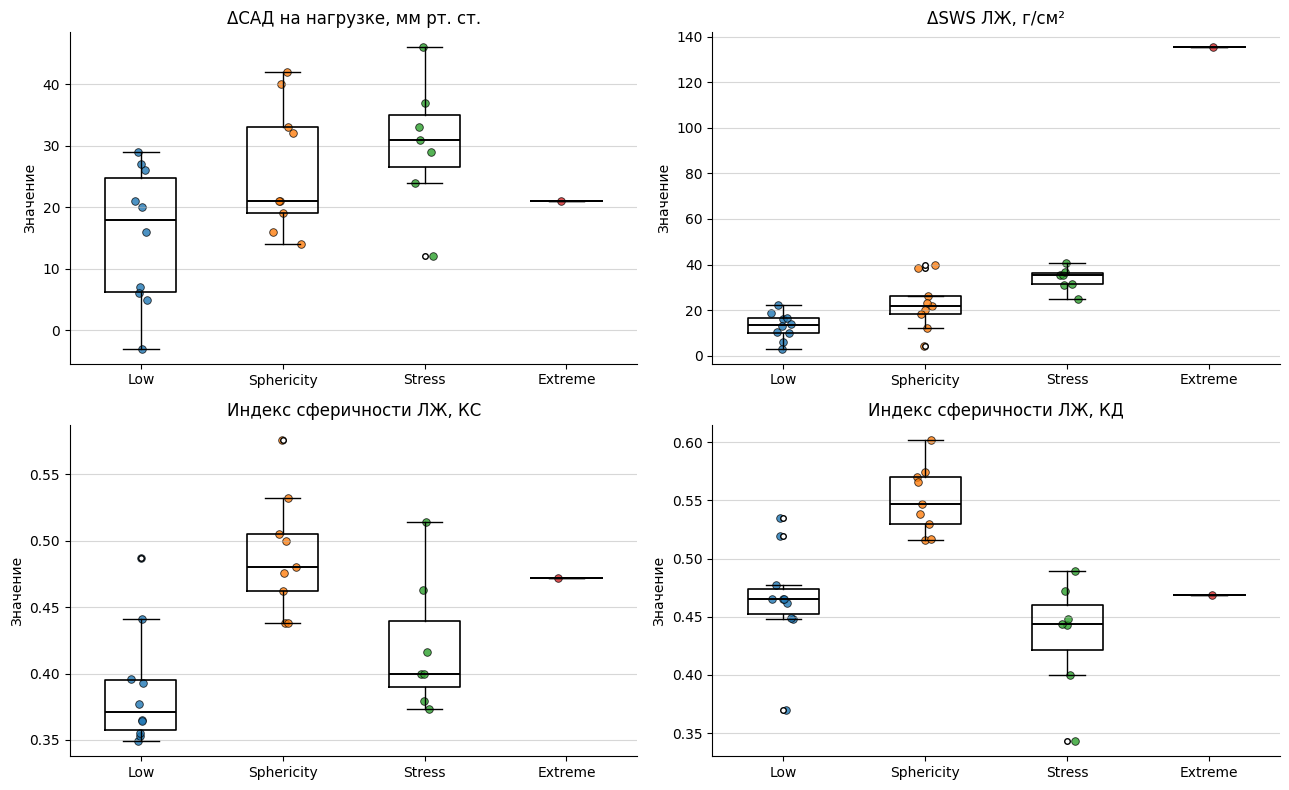

Рисунок сохранён: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\outputs\05_chords_adaptation_costs\figures\01_adaptation_variables_by_phenotype_boxplots.png


In [30]:
# ============================================================
# 8. Boxplot: переменные механизма адаптации по фенотипам
# ============================================================

plot_df = analysis_df[
    analysis_df["adaptation_phenotype_ru"].isin(phenotype_order_ru)
].copy()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, col in zip(axes, adaptation_vars):
    data_by_group = [
        plot_df.loc[
            plot_df["adaptation_phenotype_ru"] == group,
            col
        ].dropna()
        for group in phenotype_order_ru
    ]

    ax.boxplot(
        data_by_group,
        patch_artist=False,
        widths=0.5,
        boxprops=dict(color="black", linewidth=1.2),
        medianprops=dict(color="black", linewidth=1.4),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=4,
        ),
    )

    # точки поверх boxplot
    for i, values in enumerate(data_by_group, start=1):
        jitter = np.random.normal(loc=i, scale=0.035, size=len(values))
        ax.scatter(
            jitter,
            values,
            s=30,
            edgecolor="black",
            linewidth=0.6,
            alpha=0.8,
        )

    ax.set_title(pretty_names.get(col, col))
    ax.set_ylabel("Значение")
    ax.set_xticklabels(
        ["Low", "Sphericity", "Stress", "Extreme"],
        rotation=0
    )

    apply_publication_style(ax)

plt.tight_layout()

fig_path = FIGURES_DIR / "01_adaptation_variables_by_phenotype_boxplots.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

In [ ]:
# ============================================================
# 15. Цена адаптации по фенотипам: strain / DICOR / merged CV
# ============================================================

cost_vars_existing = [
    col for col in adaptation_cost_vars
    if col in main_df.columns
]

print("Переменные цены адаптации:")
for col in cost_vars_existing:
    n = main_df[col].notna().sum()
    print(f"- {col}: n={n}")

n_vars = len(cost_vars_existing)

n_cols = 2
n_rows = int(np.ceil(n_vars / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(13, 4.2 * n_rows)
)

axes = np.array(axes).flatten()

for ax, col in zip(axes, cost_vars_existing):
    data_by_group = [
        main_df.loc[
            main_df["adaptation_phenotype_ru"] == group,
            col
        ].dropna()
        for group in main_phenotype_order_ru
    ]

    ax.boxplot(
        data_by_group,
        patch_artist=False,
        widths=0.5,
        boxprops=dict(color="black", linewidth=1.2),
        medianprops=dict(color="black", linewidth=1.4),
        whiskerprops=dict(color="black", linewidth=1.0),
        capprops=dict(color="black", linewidth=1.0),
        flierprops=dict(
            marker="o",
            markerfacecolor="white",
            markeredgecolor="black",
            markersize=4,
        ),
    )

    for i, values in enumerate(data_by_group, start=1):
        jitter = np.random.normal(loc=i, scale=0.035, size=len(values))
        ax.scatter(
            jitter,
            values,
            s=32,
            edgecolor="black",
            linewidth=0.6,
            alpha=0.8,
        )

    ax.set_title(pretty_names.get(col, col))
    ax.set_ylabel("Значение")
    ax.set_xticklabels(["Low", "Sphericity", "Stress"])

    apply_publication_style(ax)

# Убираем пустые оси, если число графиков нечётное
for ax in axes[len(cost_vars_existing):]:
    ax.axis("off")

plt.tight_layout()

fig_path = FIGURES_DIR / "05_adaptation_cost_by_phenotype_boxplots.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Рисунок сохранён:", fig_path)

True